In [1]:
%cd /home/dani/projects/neuroscience

/home/dani/projects/neuroscience


In [2]:
from nilearn import datasets
import nibabel as nib
import numpy as np

In [3]:
dataset_adhd = datasets.fetch_adhd(n_subjects=30)

[fetch_adhd] Dataset found in /home/dani/nilearn_data/adhd

In [4]:
dataset_adhd.func[0]

'/home/dani/nilearn_data/adhd/data/0010042/0010042_rest_tshift_RPI_voreg_mni.nii.gz'

In [5]:
img = nib.load(dataset_adhd.func[0])
data = img.get_fdata() 
print(data.shape)

(61, 73, 61, 176)


In [6]:
np.std(data)

np.float64(4230.4809039413985)

In [7]:
atlas = datasets.fetch_atlas_msdl()
coords = atlas.region_coords
coords

[fetch_atlas_msdl] Dataset found in /home/dani/nilearn_data/msdl_atlas

[[-53.28, -8.88, 32.36],
 [53.47, -6.49, 27.52],
 [1.18, -74.54, 10.79],
 [-45.8, -64.78, 31.84],
 [-0.2, -55.21, 29.87],
 [-0.15, 51.42, 7.58],
 [51.66, -59.34, 28.88],
 [0.41, -91.05, 1.58],
 [-1.48, -27.93, 61.5],
 [40.1, 20.96, 44.72],
 [37.83, 55.49, 1.22],
 [47.53, -52.42, 43.06],
 [62.53, -32.99, -9.14],
 [-0.91, -2.75, 6.15],
 [-41.66, -59.04, 44.61],
 [-39.04, 19.28, 43.27],
 [-40.08, 50.65, 0.81],
 [-29.39, -59.43, 44.2],
 [31.6, -58.09, 45.69],
 [-30.54, -85.14, 9.1],
 [-24.29, -74.28, -11.74],
 [33.4, -77.96, 4.31],
 [-28.17, 46.32, 21.56],
 [-0.45, 34.06, 20.73],
 [28.38, 47.72, 22.13],
 [-52.12, -17.92, 13.28],
 [52.61, -13.65, 12.11],
 [-55.52, -43.77, 10.08],
 [-48.66, 25.11, 5.7],
 [-3.39, 17.19, 63.52],
 [54.42, -29.5, -2.72],
 [52.38, 29.39, 2.93],
 [1.05, -58.49, -23.91],
 [-1.44, -59.12, 55.25],
 [-41.33, 13.63, 2.7],
 [1.05, 9.2, 46.43],
 [43.01, 14.3, 2.79],
 [-47.85, -32.07, 41.9],
 [48.36, -29.04, 43.13]]

In [8]:
atlas_filename = atlas["maps"]
atlas_filename

'/home/dani/nilearn_data/msdl_atlas/MSDL_rois/msdl_rois.nii'

/tmp/ipykernel_13709/1433428784.py:9: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  mean_fmri_img = mean_img(img)


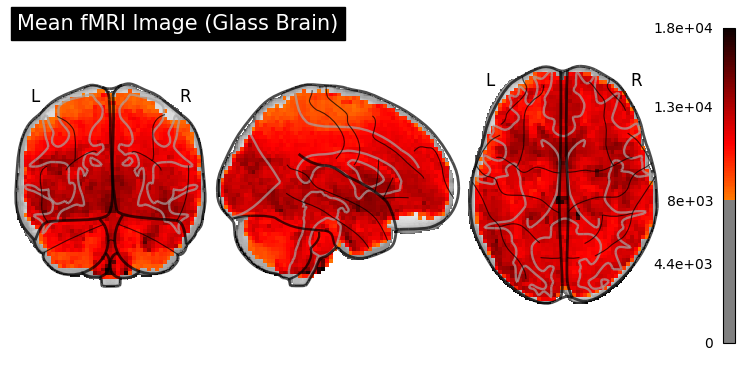

In [9]:
from nilearn import plotting, datasets
from nilearn.image import mean_img, resample_to_img
import matplotlib.pyplot as plt

# Assuming 'img' is your loaded fMRI image from the previous step

# Extract the mean image across the time dimension for visualization
# This converts the 4D fMRI data into a 3D image
mean_fmri_img = mean_img(img)
template = datasets.load_mni152_template(resolution=1)
# Plotting the mean fMRI image in "glass brain" view
plotting.plot_glass_brain(mean_fmri_img, bg_img=template, display_mode='ortho', title='Mean fMRI Image (Glass Brain)')
plt.show()

In [10]:
dataset_adhd.confounds

['/home/dani/nilearn_data/adhd/data/0010042/0010042_regressors.csv',
 '/home/dani/nilearn_data/adhd/data/0010064/0010064_regressors.csv',
 '/home/dani/nilearn_data/adhd/data/0010128/0010128_regressors.csv',
 '/home/dani/nilearn_data/adhd/data/0021019/0021019_regressors.csv',
 '/home/dani/nilearn_data/adhd/data/0023008/0023008_regressors.csv',
 '/home/dani/nilearn_data/adhd/data/0023012/0023012_regressors.csv',
 '/home/dani/nilearn_data/adhd/data/0027011/0027011_regressors.csv',
 '/home/dani/nilearn_data/adhd/data/0027018/0027018_regressors.csv',
 '/home/dani/nilearn_data/adhd/data/0027034/0027034_regressors.csv',
 '/home/dani/nilearn_data/adhd/data/0027037/0027037_regressors.csv',
 '/home/dani/nilearn_data/adhd/data/1019436/1019436_regressors.csv',
 '/home/dani/nilearn_data/adhd/data/1206380/1206380_regressors.csv',
 '/home/dani/nilearn_data/adhd/data/1418396/1418396_regressors.csv',
 '/home/dani/nilearn_data/adhd/data/1517058/1517058_regressors.csv',
 '/home/dani/nilearn_data/adhd/dat

In [11]:
atlas.maps

'/home/dani/nilearn_data/msdl_atlas/MSDL_rois/msdl_rois.nii'

In [12]:
dataset_adhd.func[0]

'/home/dani/nilearn_data/adhd/data/0010042/0010042_rest_tshift_RPI_voreg_mni.nii.gz'

In [ ]:
from nilearn.maskers import NiftiMapsMasker

masker = NiftiMapsMasker(
    maps_img=atlas["maps"],
    standardize="zscore_sample",
    standardize_confounds=True,
    memory="nilearn_cache",
    verbose=0,
)

for i in range(len(dataset_adhd.func)):
    time_series = masker.fit_transform(dataset_adhd.func[i], confounds=dataset_adhd.confounds[i])
    np.save(f"data_processed/adhd/timeseries_{i}.npy", time_series)

/home/dani/projects/neuroscience/.venv/lib/python3.11/site-packages/sklearn/utils/_set_output.py:316: UserWarning: memory_level is currently set to 0 but a Memory object has been provided. Setting memory_level to 1.
  data_to_wrap = f(self, X, *args, **kwargs)


/home/dani/projects/neuroscience/.venv/lib/python3.11/site-packages/sklearn/covariance/_graph_lasso.py:168: RuntimeWarning: invalid value encountered in multiply
  precision_[indices != idx, idx] = -precision_[idx, idx] * coefs
/home/dani/projects/neuroscience/.venv/lib/python3.11/site-packages/sklearn/covariance/_graph_lasso.py:169: RuntimeWarning: invalid value encountered in multiply
  precision_[idx, indices != idx] = -precision_[idx, idx] * coefs
/home/dani/projects/neuroscience/.venv/lib/python3.11/site-packages/sklearn/covariance/_graph_lasso.py:170: RuntimeWarning: invalid value encountered in dot
  coefs = np.dot(sub_covariance, coefs)
/home/dani/projects/neuroscience/.venv/lib/python3.11/site-packages/sklearn/covariance/_graph_lasso.py:166: RuntimeWarning: invalid value encountered in dot
  - np.dot(covariance_[indices != idx, idx], coefs)
/home/dani/projects/neuroscience/.venv/lib/python3.11/site-packages/sklearn/covariance/_graph_lasso.py:166: RuntimeWarning: invalid value 

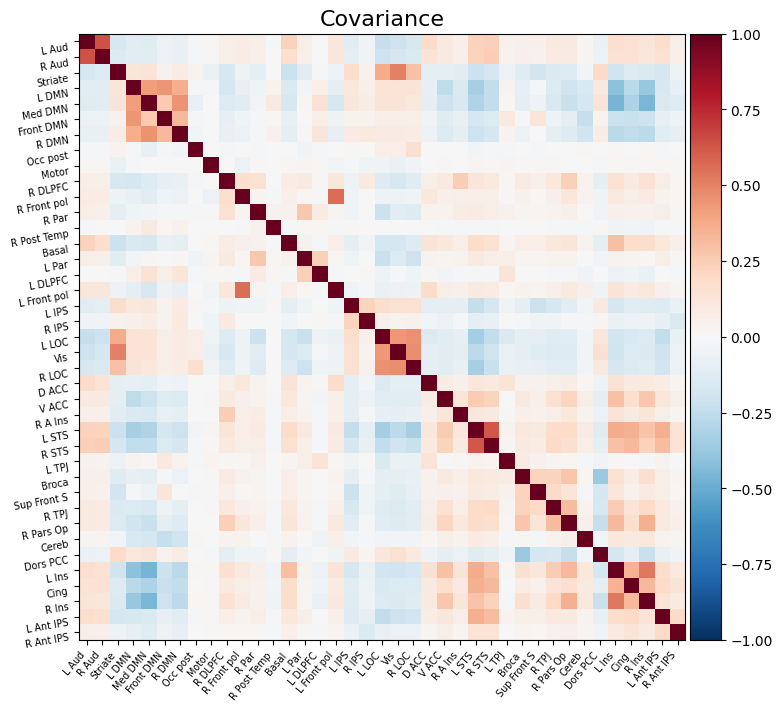

In [ ]:
from sklearn.covariance import GraphicalLassoCV
from nilearn import plotting


estimator = GraphicalLassoCV()
estimator.fit(time_series)
labels = atlas["labels"]

# Display the covariance

# The covariance can be found at estimator.covariance_
plotting.plot_matrix(
    estimator.covariance_,
    labels=labels,
    figure=(9, 7),
    vmax=1,
    vmin=-1,
    title="Covariance",
)